# **Analysis and Prediction of Diabetes Using Clinical and Demographic Health Indicators**

---

## **1️⃣ Project Overview**

Diabetes is a chronic metabolic disease that poses a significant global health challenge. Early detection and prevention are critical for reducing complications and improving patient outcomes. This project analyzes a medical dataset provided by the National Institute of Diabetes and Digestive and Kidney Diseases to predict the likelihood of diabetes based on clinical and demographic health indicators.

The dataset contains diagnostic measurements from 768 female patients of Pima Indian heritage, all aged 21 years or older. By applying data science and data mining techniques, this project aims to explore patterns in the data, identify key risk factors, and develop predictive models to classify whether a patient has diabetes.

---

## **2️⃣ Science Question**

### **Research Question**
**Which physiological factors have the strongest influence on the likelihood of developing diabetes among the individuals in the dataset?**

This question focuses on understanding the relationships between medical predictor variables—such as glucose level, BMI, insulin level, and age—and the diabetes outcome. The insights derived from this analysis can support early diagnosis and preventive healthcare strategies.

---

## **3️⃣ Objectives**

The objectives of this project are to:

- Understand the structure and characteristics of the diabetes dataset.
- Perform exploratory data analysis (EDA) to identify trends, correlations, and patterns.
- Determine the most influential physiological and demographic factors affecting diabetes outcomes.
- Preprocess the data to ensure quality and suitability for modeling.
- Build and evaluate machine learning models for diabetes prediction.
- Interpret results to provide actionable medical insights.

---

## **4️⃣ Data Mining Approach**

The data mining process adopted in this project includes the following steps:

1. **Data Understanding**  
   Analyze dataset structure, feature types, and medical relevance of each variable.

2. **Data Preprocessing**  
   - Identify and handle invalid or zero values in medical measurements.  
   - Normalize or scale numerical features as required.

3. **Exploratory Data Analysis (EDA)**  
   - Study feature distributions and summary statistics.  
   - Perform correlation analysis to identify relationships between predictors and outcome.  
   - Visualize key patterns using appropriate plots.

4. **Feature Selection and Engineering**  
   Select the most relevant attributes that significantly contribute to diabetes prediction.

5. **Model Building**  
   Apply supervised learning algorithms such as Logistic Regression, Decision Trees, Random Forest, or Support Vector Machines.

6. **Model Evaluation**  
   Assess model performance using metrics including accuracy, precision, recall, F1-score, and confusion matrix.

7. **Interpretation and Insights**  
   Analyze model results to answer the research question and highlight the strongest physiological predictors of diabetes.

---


## Importing Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

## Loading Data

In [2]:
df = pd.read_csv("diabetes.csv")

## Data Analysis

## Displaying the First Five Rows

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Displaying the Last Five Rows

In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## Displaying the Shape of the Dataset

In [5]:
shape = df.shape
print("Total Number of Rows:",shape[0])
print("Total Number of Columns:",shape[1])

Total Number of Rows: 768
Total Number of Columns: 9


## Displaying the column Names

In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## Displaying information of the Data Set

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Feature Types in the Dataset

**Categorical Variables:**

- Outcome – Diabetes result (1 = Yes, 0 = No)

**Numerical Variables:**

- Pregnancies – Number of pregnancies

- Glucose – Blood glucose level

- BloodPressure – Blood pressure measurement

- SkinThickness – Triceps skin fold thickness

- Insulin – Blood insulin level

- BMI – Body mass index

- DiabetesPedigreeFunction – Diabetes pedigree function (genetic risk factor)

- Age – Age of the patient

## Displaying the Duplicate values

In [8]:
df.duplicated().any()

np.False_

## Displaying the Null Values

### Displaying Each Column Null Values there ot not

In [9]:
df.isnull().any()

,0
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


## Displaying Each Column Count of the Null Values

In [10]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Data Cleaning Summary
No missing values or duplicate records were identified in the dataset.
Therefore, no imputation or row removal was required. This verification step ensures the
dataset is suitable for downstream analysis..

### Displaying the Basic Statistical Analysis

In [11]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Displaying Unique Values

In [12]:
df['Outcome'].unique()

array([1, 0])

## displaying count of unique values

In [13]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


# Exploratory Data Analysis (EDA)

### Plot 1: Outcome Variable Analysis

This pie chart shows the proportion of diabetic (1) and non-diabetic (0) patients in the dataset.  
It helps us understand the class balance between the two categories.  
We observe that non-diabetic patients form the majority (~65%), while diabetic patients make up about 35%.  
This indicates a moderate class imbalance in the dataset.


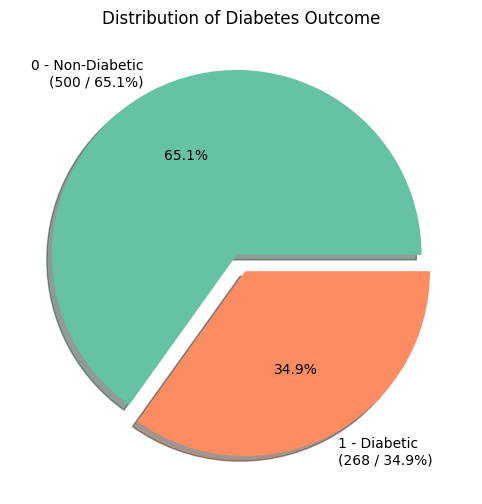

In [14]:
outcome_counts = df['Outcome'].value_counts()
total_patients = outcome_counts.sum()
percentages = outcome_counts / total_patients * 100

# Create Labels
labels = [f'0 - Non-Diabetic\n({outcome_counts[0]} / {percentages[0]:.1f}%)',
          f'1 - Diabetic\n({outcome_counts[1]} / {percentages[1]:.1f}%)']

# Define Color Palettes (Choose One)


# Option 1: Simple contrasting colors
colors1 = ['#1f77b4', '#ff7f0e']  # Blue / Orange

# Option 2: Pastel palette
colors2 = sns.color_palette("pastel", 2)

# Option 3: Set2 palette (bright & professional)
colors3 = sns.color_palette("Set2", 2)

# Option 4: Custom hex codes (Purple / Green)
colors4 = ['#6a0dad', '#2ca02c']


# Plot Pie Chart
plt.figure(figsize=(8, 6))
plt.pie(
    outcome_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors3,
    explode=(0.05, 0.05),
    shadow=True
)
plt.title('Distribution of Diabetes Outcome')
plt.show()

### Plot 2: Feature Distribution Analysis

The histograms display the distribution of each numerical feature in the dataset.  
They help identify the spread, skewness, and presence of outliers in the data.  
Some features such as Insulin and BMI are right-skewed, and several medical variables contain unrealistic zero values.  
This plot is useful for detecting data quality issues before model building.

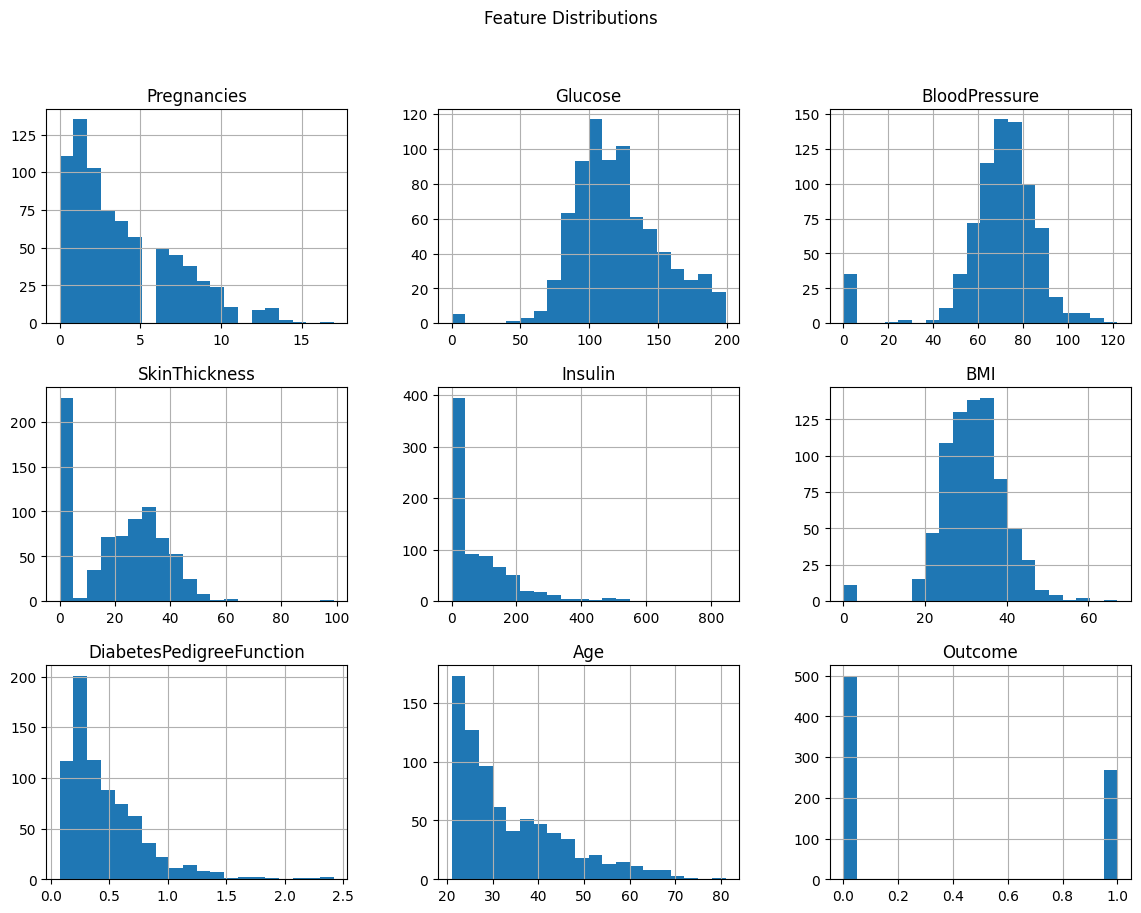

In [15]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle('Feature Distributions')
plt.show()

### Plot 3: Outcome vs Features (Medical Insight)

**Boxplots by Outcome**

The boxplots compare feature distributions between diabetic and non-diabetic patients.  

They show differences in median values, variability, and outliers for each group.  

**Glucose** shows the strongest separation between the two classes, followed by **BMI** and **Age**.  

This helps identify which features are most important for predicting diabetes.


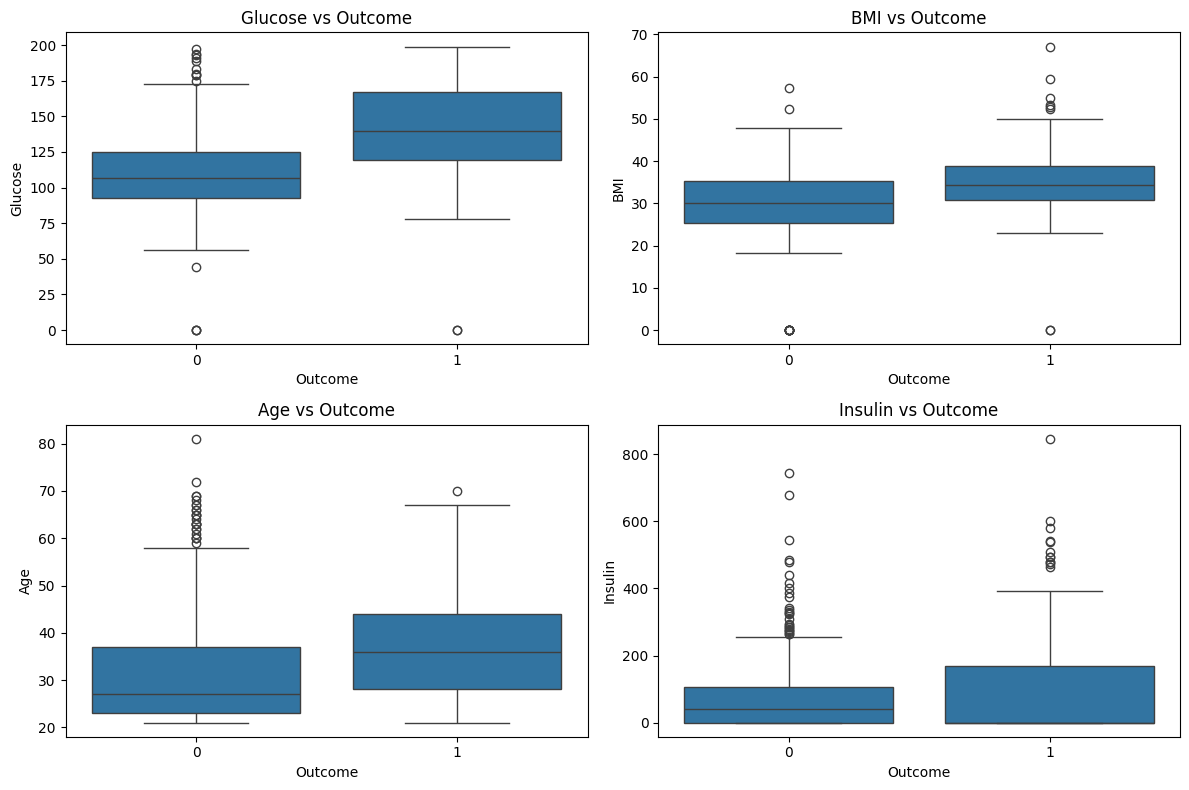

In [16]:
features = ['Glucose','BMI','Age','Insulin']

plt.figure(figsize=(12,8))
for i, col in enumerate(features,1):
    plt.subplot(2,2,i)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} vs Outcome')
plt.tight_layout()
plt.show()

### Plot 4: Correlation Analysis

**Shows linear relationships**

- Glucose has strong correlation with Outcome

- Weak multicollinearity (good for ML)

Correlation Between All Columns:


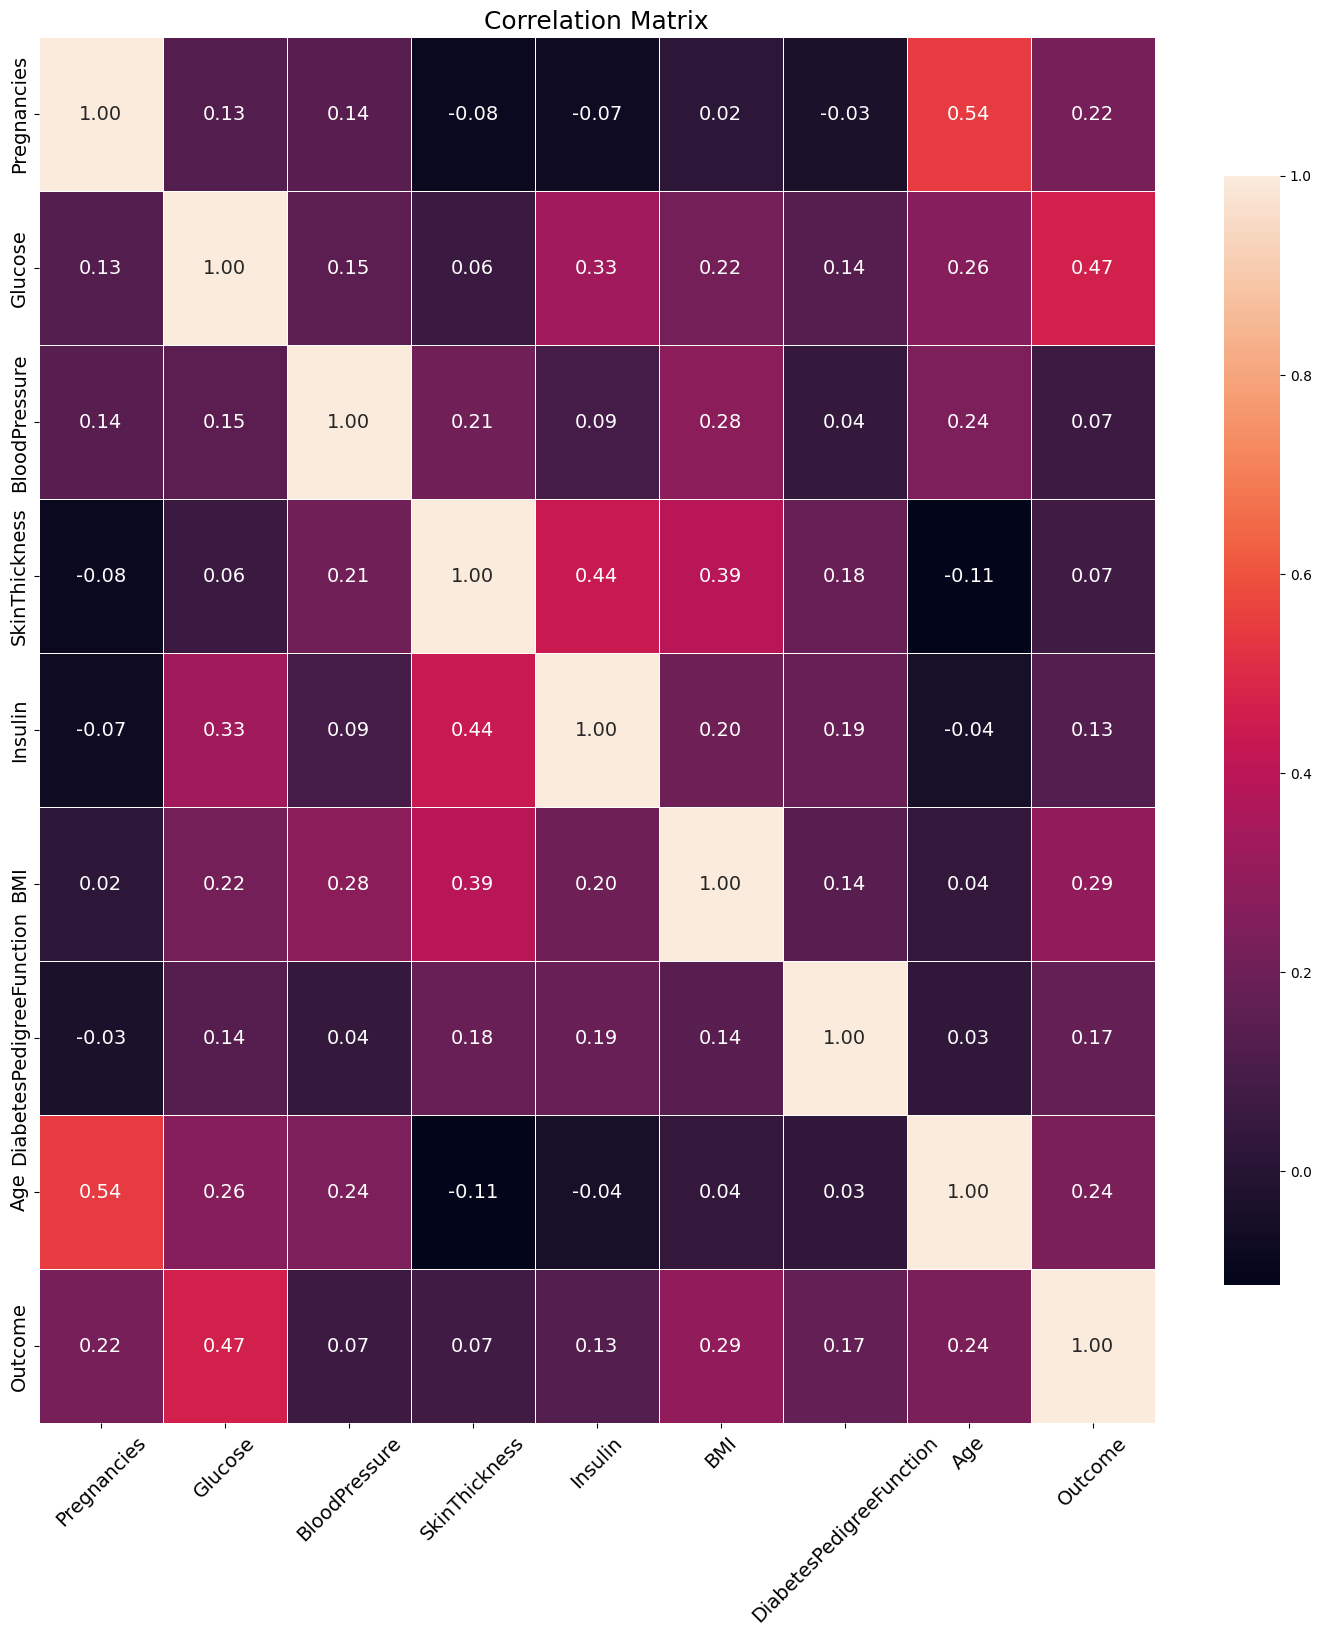

In [17]:
print("Correlation Between All Columns:")

plt.figure(figsize=(18, 18))

sns.heatmap(
    df.corr(),
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 14},
    cbar_kws={"shrink": 0.8}
)

plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.title("Correlation Matrix", fontsize=18)

plt.show()

### Plot 5: Pairplot (Relationship Visualization)

The pairplot shows relationships between Glucose, BMI, and Age, with colors indicating diabetes outcome.
Glucose shows the clearest separation between diabetic and non-diabetic patients.
However, there is overlap between classes, so multiple features are needed for accurate prediction.ction.

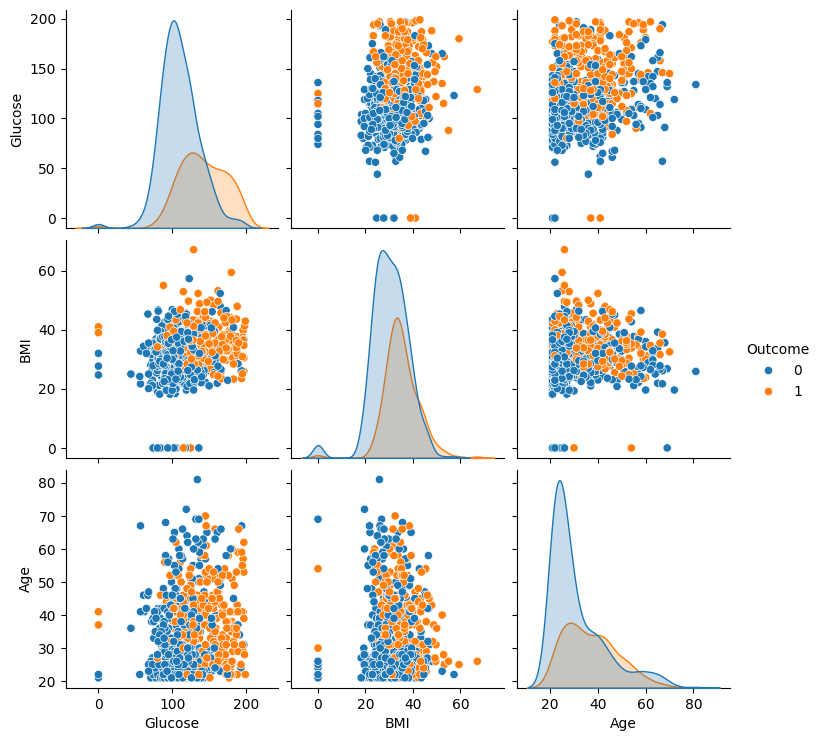

In [18]:
sns.pairplot(df[['Glucose','BMI','Age','Outcome']], hue='Outcome')
plt.show()

### Plot 6: Age vs Glucose Scatter Plot

This scatter plot shows the relationship between **Age** and **Glucose** levels, colored by diabetes outcome.  

Diabetic patients are mostly concentrated at higher glucose levels across different ages.  

Although **Age** contributes to diabetes risk, **Glucose** appears to be the stronger predictor.  

Some overlap between classes indicates the problem is not perfectly sepa

We can see that higher glucose levels are strongly associated with diabetes, while age shows weaker influence.”rable.

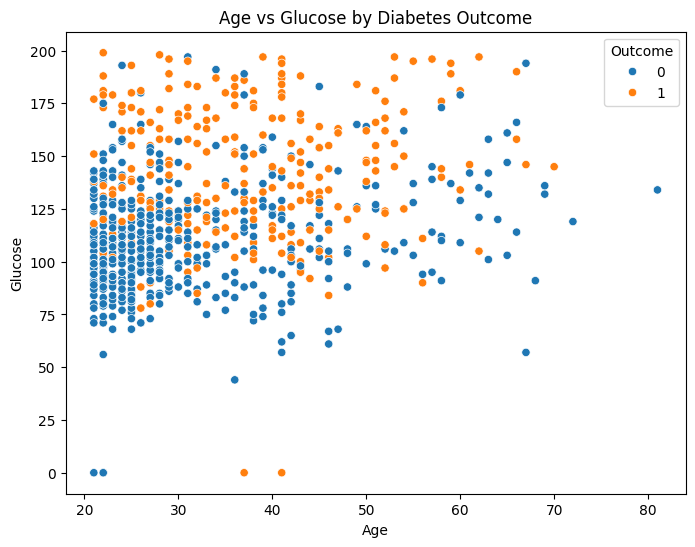

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Glucose', hue='Outcome', data=df)
plt.title('Age vs Glucose by Diabetes Outcome')
plt.show()


### Plot 7: Zero-Value Analysis

**Zero values represent missing medical data → require imputation**

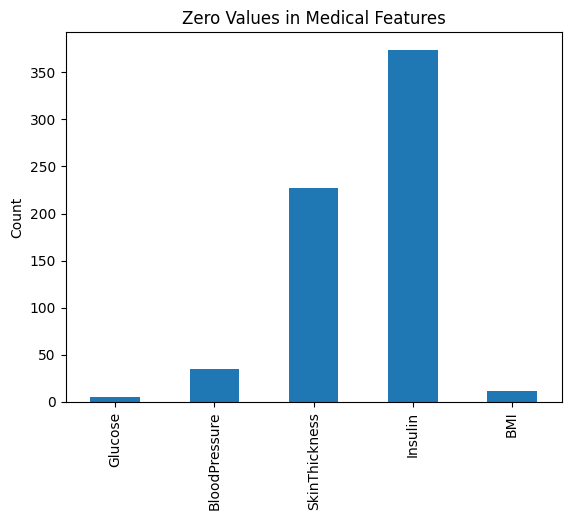

In [20]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
(df[zero_cols] == 0).sum().plot(kind='bar')
plt.title('Zero Values in Medical Features')
plt.ylabel('Count')
plt.show()

# Data Cleaning

In [21]:
## Identify Medically Invalid Zero Values
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[zero_cols] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [22]:
## Replace invalid zeros with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

## Checking Null values
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [23]:
## Remove rows containing NULL values
df = df.dropna()

In [24]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Feature Distribution After Cleaning

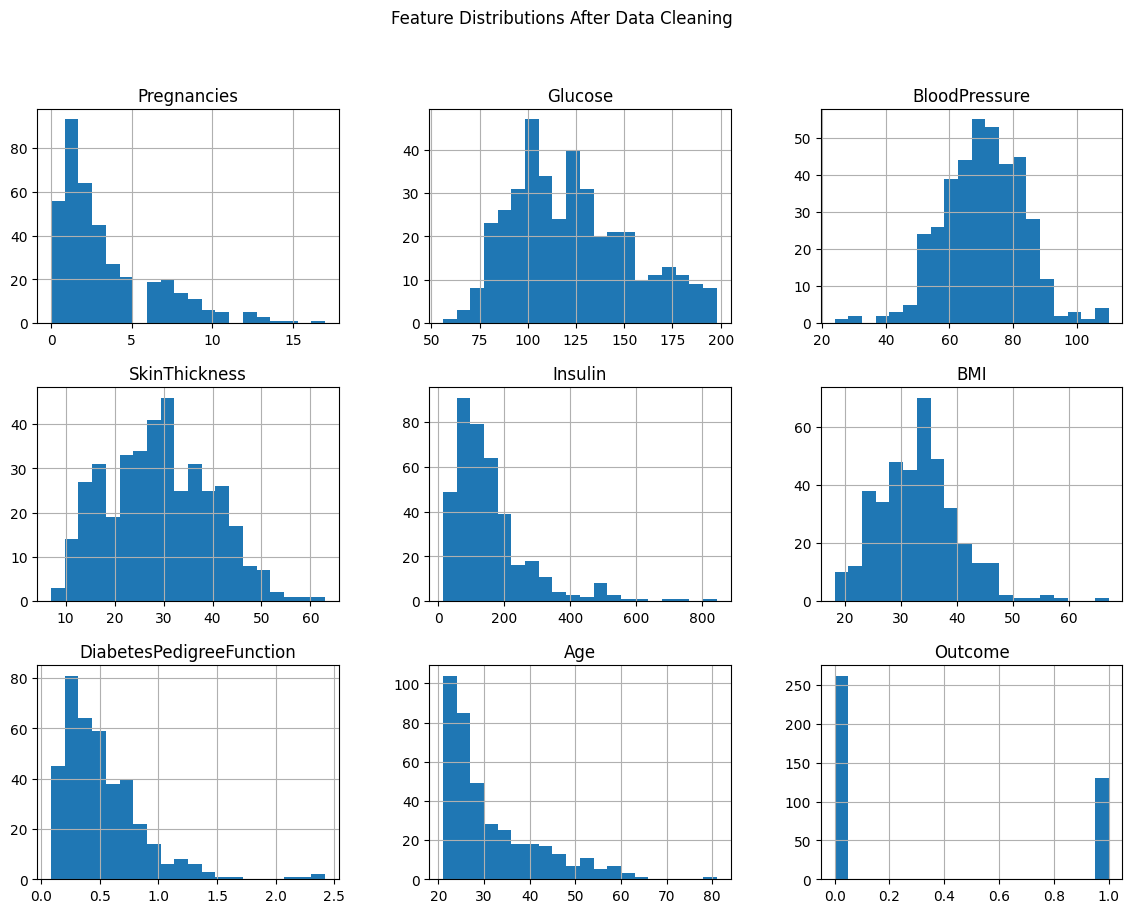

In [25]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle('Feature Distributions After Data Cleaning')
plt.show()


##  Model Building and Evaluation

In [26]:
X= df.drop('Outcome', axis=1)
y= df['Outcome']

## Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Model Building

We will train **four suitable medical classification models** for this task:

| Model | Why It Is Appropriate |
|-------|-----------------------|
| **Gradient Boosting** | High predictive performance by sequentially correcting errors, effective for complex medical datasets |
| **XGBoost** | Optimized gradient boosting with regularization, widely used for achieving state-of-the-art results in structured medical data |
| **AdaBoost** | Focuses on difficult-to-classify cases, improving performance on challenging medical classification tasks |
| **Decision Tree** | Easy to interpret and visualize, useful for medical decision-making explanations |

---

These models provide a balance between **advanced predictive performance and interpretability**, which is essential in medical applicatcations.


## Model

In [28]:
# 1️⃣ Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# 2️⃣ XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 3️⃣ AdaBoost
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

# 4️⃣ Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


## Model Evaluation (Medical-Relevant Metrics)

We evaluate the model using clinically meaningful metrics:

- **Accuracy** → Overall performance  
- **Precision** → False positive control  
- **Recall** → **VERY important** (missed diabetic patients)  
- **F1 Score** → Balance between precision and recall  
- **Confusion Matrix** → Clinical usefulness


In [29]:
def evaluate_model(name, y_test, y_pred):
    print("Model:", name)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*40)

## Evaluation

In [30]:
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("XGBoost", y_test, y_pred_xgb)
evaluate_model("AdaBoost", y_test, y_pred_ada)
evaluate_model("Decision Tree", y_test, y_pred_dt)

Model: Gradient Boosting
Accuracy : 0.7848101265822784
Precision: 0.6956521739130435
Recall   : 0.6153846153846154
F1 Score : 0.6530612244897959
Confusion Matrix:
 [[46  7]
 [10 16]]
----------------------------------------
Model: XGBoost
Accuracy : 0.810126582278481
Precision: 0.6896551724137931
Recall   : 0.7692307692307693
F1 Score : 0.7272727272727273
Confusion Matrix:
 [[44  9]
 [ 6 20]]
----------------------------------------
Model: AdaBoost
Accuracy : 0.8481012658227848
Precision: 0.7916666666666666
Recall   : 0.7307692307692307
F1 Score : 0.76
Confusion Matrix:
 [[48  5]
 [ 7 19]]
----------------------------------------
Model: Decision Tree
Accuracy : 0.7215189873417721
Precision: 0.5666666666666667
Recall   : 0.6538461538461539
F1 Score : 0.6071428571428571
Confusion Matrix:
 [[40 13]
 [ 9 17]]
----------------------------------------


## Compare Model Performance

In [31]:
results = pd.DataFrame({
    'Model': ['Gradient Boosting', 'XGBoost', 'AdaBoost', 'Decision Tree'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_dt)
    ],

    'Recall': [
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_ada),
        recall_score(y_test, y_pred_dt)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_ada),
        f1_score(y_test, y_pred_dt)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Recall,F1 Score
2,AdaBoost,0.848101,0.730769,0.760000
1,XGBoost,0.810127,0.769231,0.727273
0,Gradient Boosting,0.784810,0.615385,0.653061
3,Decision Tree,0.721519,0.653846,0.607143


## Confusion Matrix

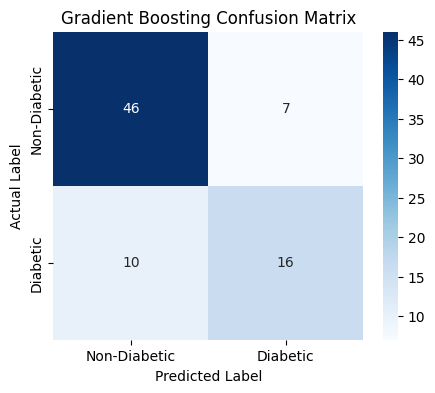

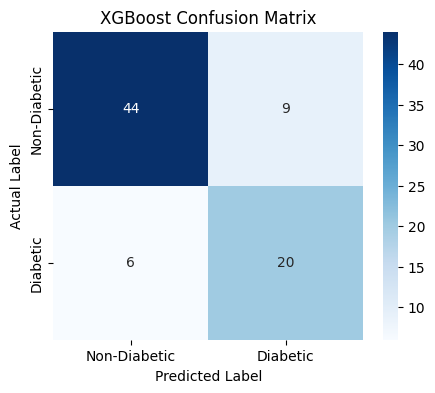

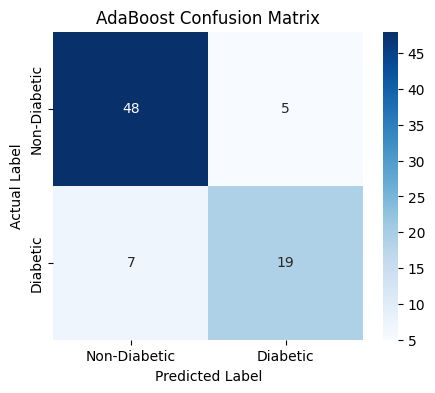

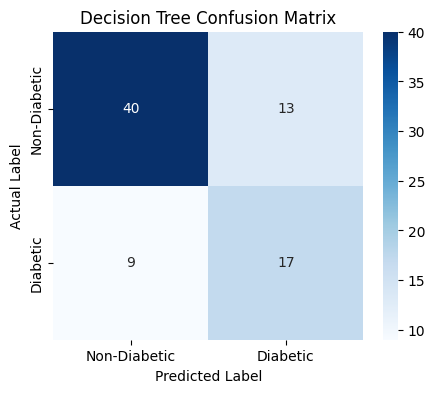

In [32]:
def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Diabetic','Diabetic'],
                yticklabels=['Non-Diabetic','Diabetic'])

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_test, y_pred_gb,  "Gradient Boosting Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_ada, "AdaBoost Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_dt,  "Decision Tree Confusion Matrix")

## Feature Importance
- This answers your research question Which physiological factors influence diabetes most?

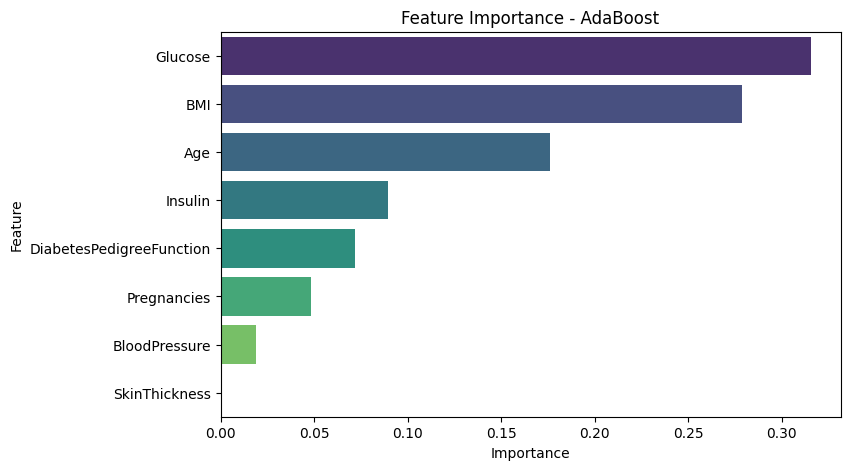

In [33]:
importance = ada_model.feature_importances_
features = X.columns  # make sure X is your training DataFrame

# Create a DataFrame for plotting
imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette="viridis")
plt.title("Feature Importance - AdaBoost")
plt.show()

## ROC Curve

AdaBoost AUC Score: 0.8813497822931785


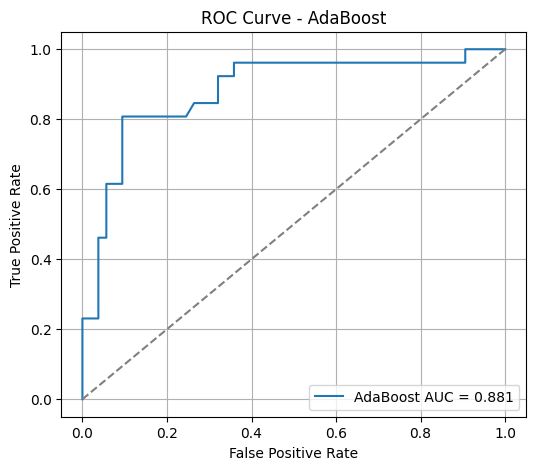

In [34]:
# Get predicted probabilities for the positive class
y_prob = ada_model.predict_proba(X_test)[:,1]

# Print AUC Score
print("AdaBoost AUC Score:", roc_auc_score(y_test, y_prob))

# Compute FPR, TPR
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AdaBoost AUC = {:.3f}".format(roc_auc_score(y_test, y_prob)))
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## HYPERPARAMETER TUNING

In [35]:
# ================================
# Model Evaluation Function
# ================================
def evaluate_model(name, y_test, y_pred):
    print("Model:", name)
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*50)

# ================================
# Define models and hyperparameters
# ================================
models = {
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {
            'n_estimators':[100,200,300],
            'learning_rate':[0.01,0.05,0.1],
            'max_depth':[2,3,4],
            'subsample':[0.8,1]
        }
    },
    "XGBoost": {
        "estimator": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "params": {
            'n_estimators':[100,200,300],
            'learning_rate':[0.01,0.05,0.1],
            'max_depth':[3,4,5],
            'subsample':[0.8,1],
            'colsample_bytree':[0.8,1]
        }
    },
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=42),
        "params": {
            'n_estimators':[50,100,200,300],
            'learning_rate':[0.01,0.1,0.5,1]
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            'max_depth':[3,5,7,10,None],
            'min_samples_split':[2,5,10],
            'min_samples_leaf':[1,2,4],
            'criterion':['gini','entropy']
        }
    }
}

# ================================
# Train, predict, evaluate
# ================================
results_list = []

for name, model_info in models.items():
    grid = GridSearchCV(model_info["estimator"], model_info["params"], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    print(f"Best Parameters ({name}):", grid.best_params_)
    evaluate_model(name, y_test, y_pred)

    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# ================================
# Final Comparison Table
# ================================
results = pd.DataFrame(results_list).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("\nFinal Model Comparison")
print(results)

Best Parameters (Gradient Boosting): {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1}
Model: Gradient Boosting
Accuracy : 0.7721518987341772
Precision: 0.6428571428571429
Recall   : 0.6923076923076923
F1 Score : 0.6666666666666666
Confusion Matrix:
 [[43 10]
 [ 8 18]]
--------------------------------------------------
Best Parameters (XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Model: XGBoost
Accuracy : 0.810126582278481
Precision: 0.72
Recall   : 0.6923076923076923
F1 Score : 0.7058823529411765
Confusion Matrix:
 [[46  7]
 [ 8 18]]
--------------------------------------------------
Best Parameters (AdaBoost): {'learning_rate': 0.5, 'n_estimators': 100}
Model: AdaBoost
Accuracy : 0.8354430379746836
Precision: 0.782608695652174
Recall   : 0.6923076923076923
F1 Score : 0.7346938775510204
Confusion Matrix:
 [[48  5]
 [ 8 18]]
--------------------------------------------------
Best Parameters (

## Learning Curves for Gradient Boosting, XGBoost, and AdaBoost

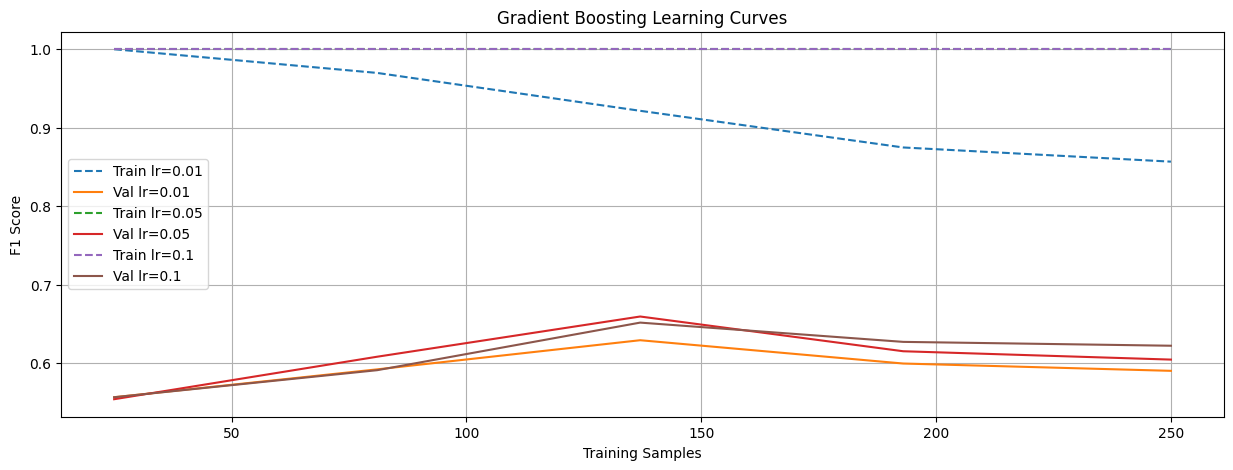

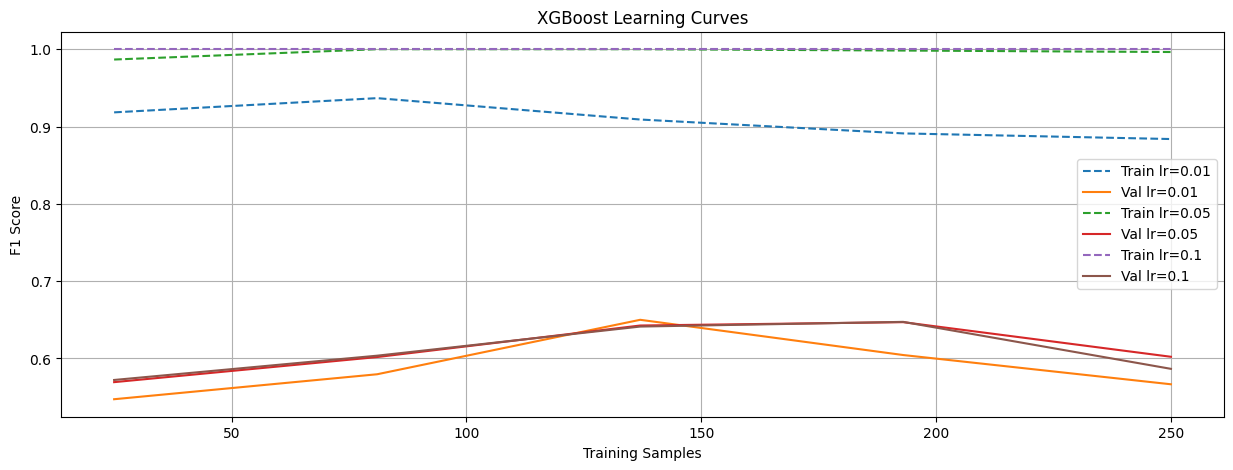

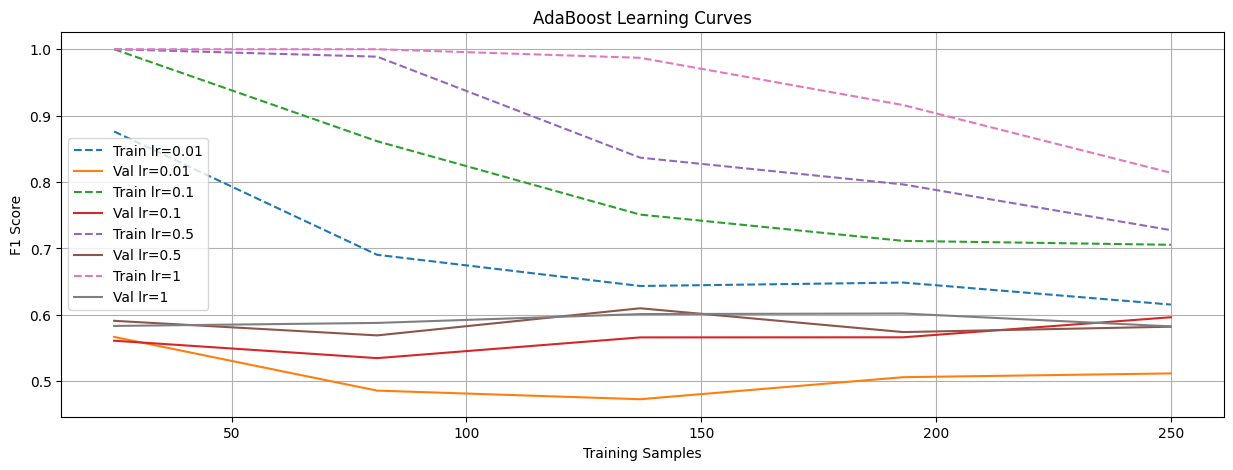

In [36]:
def plot_learning_curve(model, X, y, learning_rates, title):
    plt.figure(figsize=(15,5))

    for lr in learning_rates:
        # Update model with learning_rate (works for GradientBoosting, AdaBoost, XGB)
        model.set_params(learning_rate=lr)

        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y, cv=5, scoring='f1', n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
        )

        train_mean = np.mean(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)

        plt.plot(train_sizes, train_mean, '--', label=f"Train lr={lr}")
        plt.plot(train_sizes, val_mean, '-', label=f"Val lr={lr}")

    plt.title(title)
    plt.xlabel("Training Samples")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()


# ================================
# Plot Learning Curves for Each Model
# ================================
# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=3, subsample=1, random_state=42)
plot_learning_curve(gb_model, X_train, y_train, learning_rates=[0.01, 0.05, 0.1], title="Gradient Boosting Learning Curves")

# XGBoost
xgb_model = XGBClassifier(n_estimators=200, max_depth=4, subsample=1, colsample_bytree=1,
                          use_label_encoder=False, eval_metric='logloss', random_state=42)
plot_learning_curve(xgb_model, X_train, y_train, learning_rates=[0.01, 0.05, 0.1], title="XGBoost Learning Curves")

# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=200, random_state=42)
plot_learning_curve(ada_model, X_train, y_train, learning_rates=[0.01, 0.1, 0.5, 1], title="AdaBoost Learning Curves")